In [1]:
import joblib
import numpy as np

from matplotlib import pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

In [2]:
california_housing = fetch_california_housing(as_frame=True)

california_housing.frame.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
california_housing.frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
california_housing.frame.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

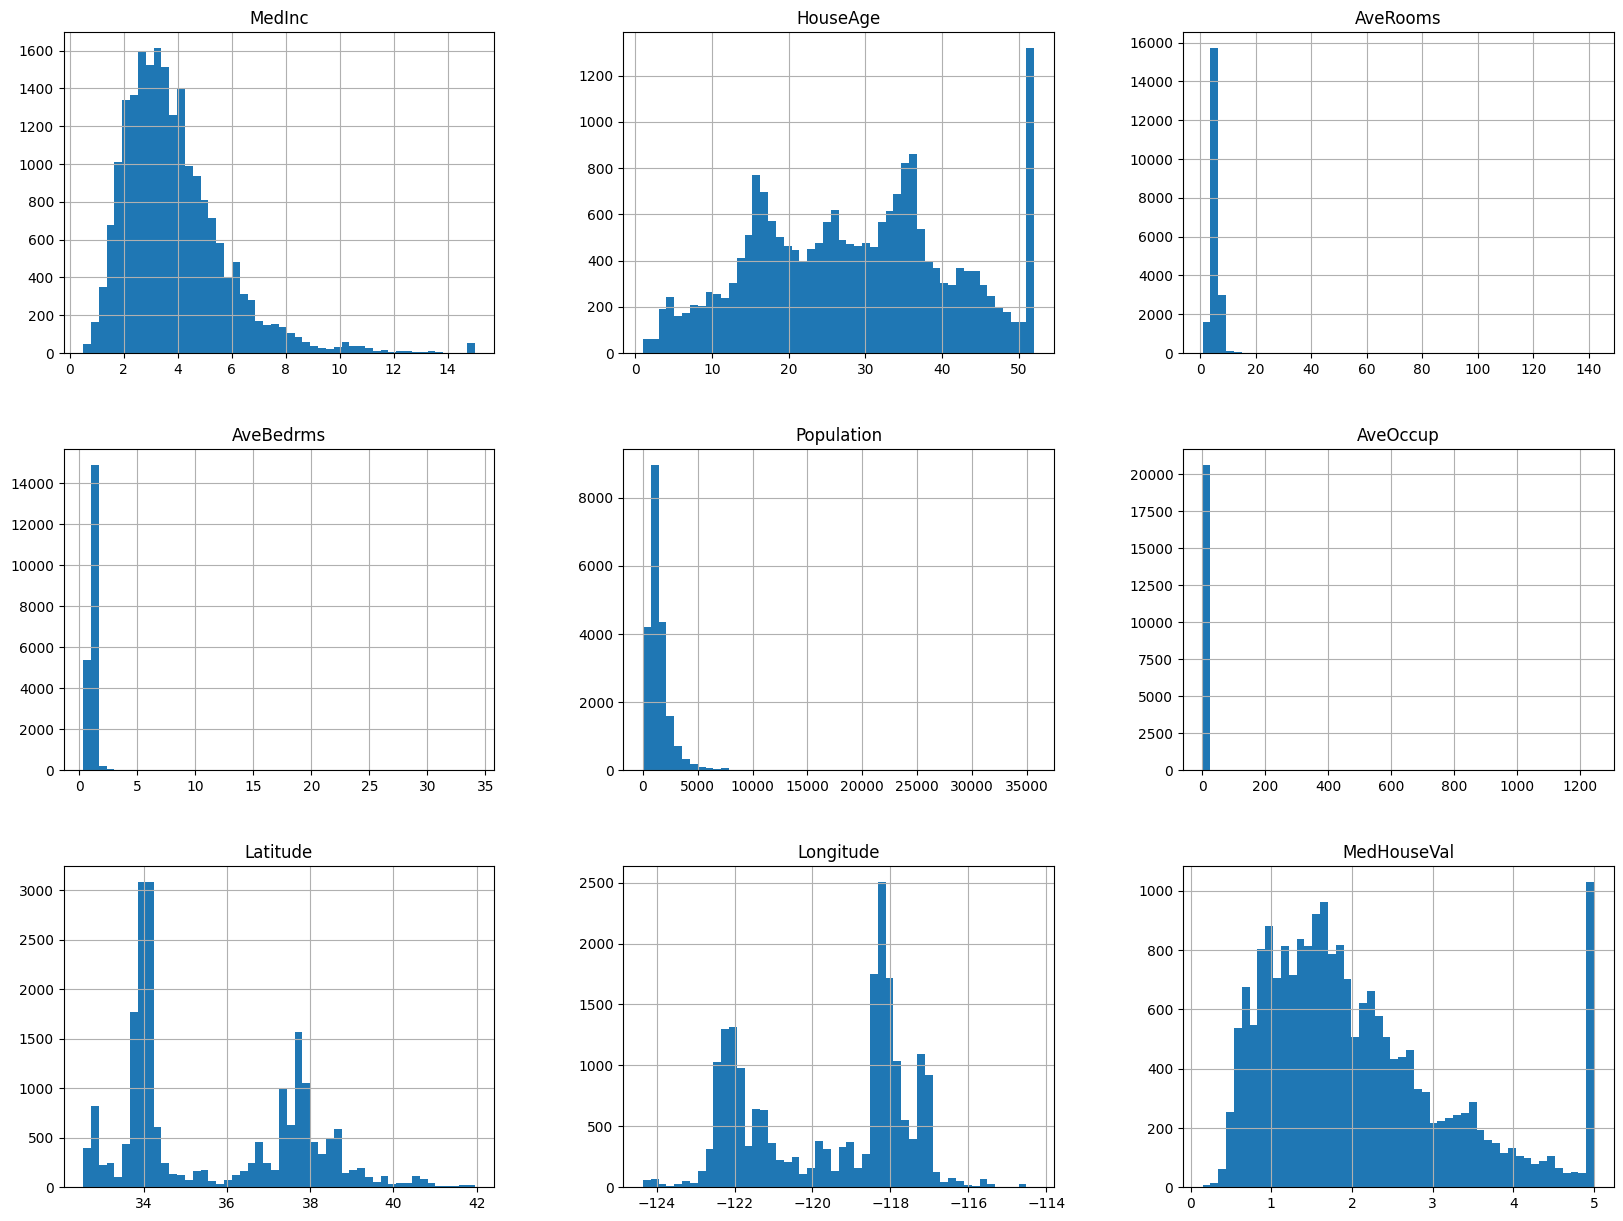

In [5]:
california_housing.frame.hist(bins=50, figsize=(20, 15))

In [6]:
train_set, test_set = train_test_split(california_housing.frame, test_size=0.2, random_state=42)

<Axes: >

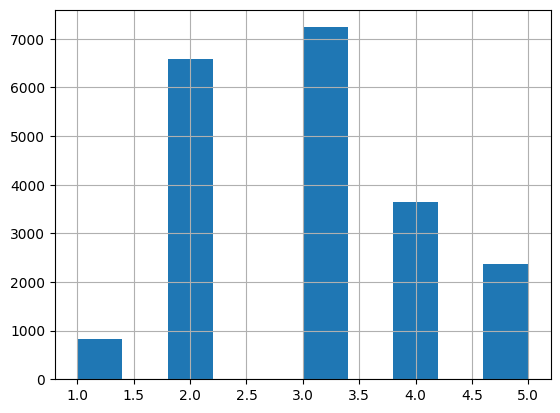

In [7]:
california_housing.frame["CatInc"] = np.ceil(california_housing.frame["MedInc"] / 1.5)
california_housing.frame["CatInc"] = california_housing.frame["CatInc"].where(california_housing.frame["CatInc"] < 5, 5.0)
california_housing.frame["CatInc"].hist()

In [8]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
strat_train_set, strat_test_set = [], []

for train_index, test_index in split.split(california_housing.frame, california_housing.frame["CatInc"]):
    strat_train_set = california_housing.frame.loc[train_index]
    strat_test_set = california_housing.frame.loc[test_index]

In [9]:
california_housing.frame["CatInc"].value_counts() / len(california_housing.frame)

CatInc
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

In [10]:
for _set in (strat_train_set, strat_test_set):
    _set.drop("CatInc", axis=1, inplace=True)

<Axes: xlabel='Longitude', ylabel='Latitude'>

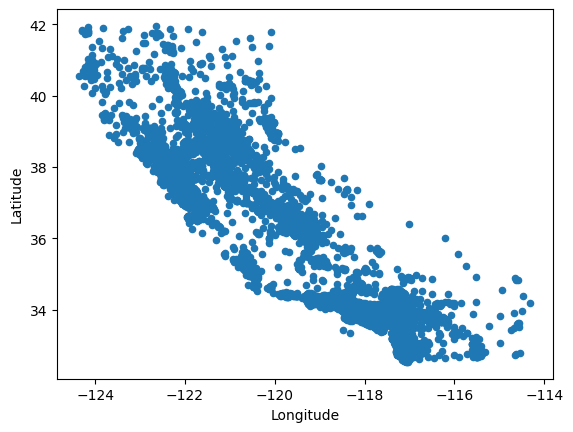

In [11]:
housing = strat_train_set.copy()

housing.plot(kind="scatter", x="Longitude", y="Latitude")

<Axes: xlabel='Longitude', ylabel='Latitude'>

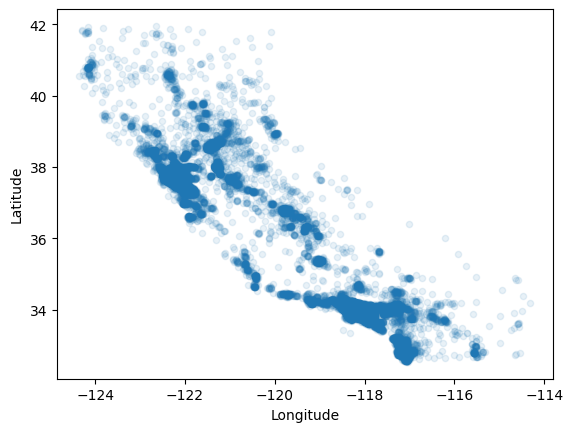

In [12]:
housing.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.1)

<Axes: xlabel='Longitude', ylabel='Latitude'>

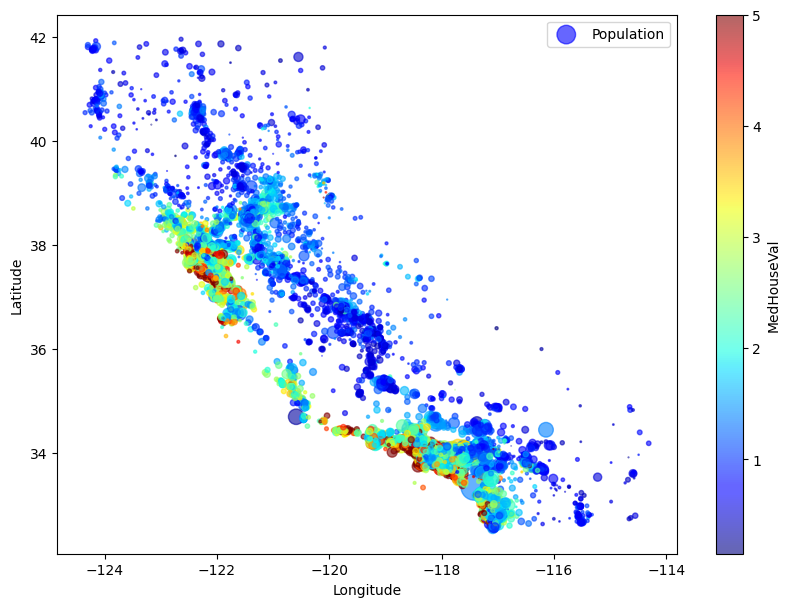

In [13]:
housing.plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.6,
             s=housing["Population"] / 100, label="Population",
             figsize=(10, 7), c="MedHouseVal", cmap=plt.get_cmap("jet"), colorbar=True)

In [14]:
corr_matrix = housing.corr()

corr_matrix["MedHouseVal"].sort_values(ascending=False).to_frame()

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.687151
AveRooms,0.146255
HouseAge,0.114146
AveOccup,-0.021991
Population,-0.026882
AveBedrms,-0.043294
Longitude,-0.047466
Latitude,-0.142673


array([[<Axes: xlabel='MedHouseVal', ylabel='MedHouseVal'>,
        <Axes: xlabel='MedInc', ylabel='MedHouseVal'>,
        <Axes: xlabel='AveRooms', ylabel='MedHouseVal'>,
        <Axes: xlabel='HouseAge', ylabel='MedHouseVal'>],
       [<Axes: xlabel='MedHouseVal', ylabel='MedInc'>,
        <Axes: xlabel='MedInc', ylabel='MedInc'>,
        <Axes: xlabel='AveRooms', ylabel='MedInc'>,
        <Axes: xlabel='HouseAge', ylabel='MedInc'>],
       [<Axes: xlabel='MedHouseVal', ylabel='AveRooms'>,
        <Axes: xlabel='MedInc', ylabel='AveRooms'>,
        <Axes: xlabel='AveRooms', ylabel='AveRooms'>,
        <Axes: xlabel='HouseAge', ylabel='AveRooms'>],
       [<Axes: xlabel='MedHouseVal', ylabel='HouseAge'>,
        <Axes: xlabel='MedInc', ylabel='HouseAge'>,
        <Axes: xlabel='AveRooms', ylabel='HouseAge'>,
        <Axes: xlabel='HouseAge', ylabel='HouseAge'>]], dtype=object)

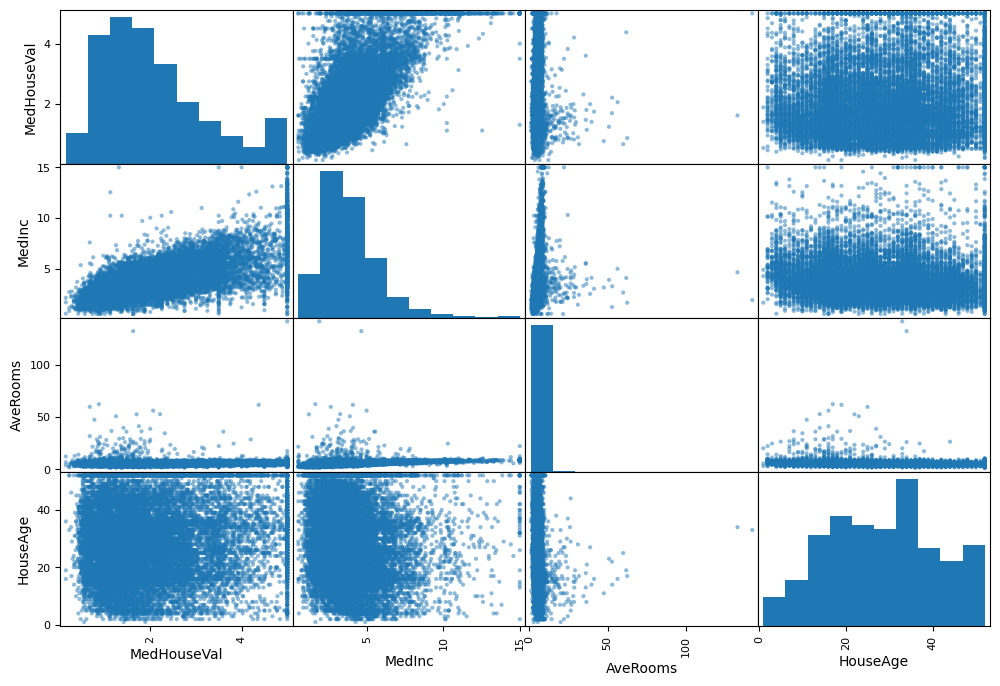

In [15]:
attributes = ["MedHouseVal", "MedInc", "AveRooms", "HouseAge"]

scatter_matrix(housing[attributes], figsize=(12, 8))

<Axes: xlabel='MedInc', ylabel='MedHouseVal'>

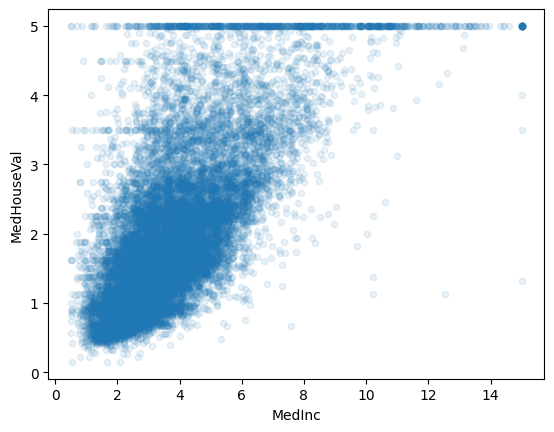

In [16]:
housing.plot(kind="scatter", x="MedInc", y="MedHouseVal", alpha=0.1)

In [17]:
housing["RoomsPerHouse"] = housing["AveRooms"] / housing["AveOccup"]
housing["BedrmsPerRoom"] = housing["AveBedrms"] / housing["AveRooms"]
housing["PopulPerOccup"] = housing["Population"] / housing["AveOccup"]

corr_matrix = housing.corr()

corr_matrix["MedHouseVal"].sort_values(ascending=False).to_frame()

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.687151
RoomsPerHouse,0.199420
AveRooms,0.146255
HouseAge,0.114146
PopulPerOccup,0.064590
AveOccup,-0.021991
Population,-0.026882
AveBedrms,-0.043294
Longitude,-0.047466


In [18]:
housing = strat_train_set.drop("MedHouseVal", axis=1)
housing_labels = strat_train_set["MedHouseVal"].copy()

In [19]:
median = housing["AveBedrms"].median()
housing["AveBedrms"] = housing["AveBedrms"].fillna(median)

In [20]:
rooms_ix, bedrooms_ix, population_ix, household_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, x, y=None):
        return self

    def transform(self, x, y=None):
        rooms_per_household = x[:, rooms_ix] / x[:, household_ix]
        population_per_household = x[:, population_ix] / x[:, household_ix]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = x[:, bedrooms_ix] / x[:, rooms_ix]
            return np.c_[x, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[x, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

In [21]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("std_scaler", StandardScaler())
])

In [22]:
housing_prepared = num_pipe.fit_transform(housing)

housing_prepared.shape

(16512, 11)

In [23]:
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = num_pipe.transform(some_data)

print("Прогнозы:", lin_reg.predict(some_data_prepared))
print("Метки:", list(some_labels))

Прогнозы: [1.03299741 2.90831239 1.64299455 1.62439762 2.52590158]
Метки: [0.721, 2.796, 0.827, 1.125, 2.383]


In [25]:
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)

lin_rmse

np.float64(0.7218651602438261)

In [26]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)

tree_rmse

np.float64(2.8665835232995054e-16)

In [28]:
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [29]:
def display_scores(_scores):
    print("Суммы оценок:", _scores)
    print("Среднее:", _scores.mean())
    print("Стандартное отклонение:", _scores.std())

display_scores(tree_rmse_scores)

Суммы оценок: [0.77386124 0.7588952  0.70867335 0.76391811 0.74041758 0.75127865
 0.74089034 0.74553019 0.69276732 0.75047078]
Среднее: 0.7426702758228381
Стандартное отклонение: 0.02342021395301973


In [30]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)

display_scores(lin_rmse_scores)

Суммы оценок: [0.74122284 0.70200679 0.70374968 0.73901956 0.71472864 0.75445188
 0.74132046 0.80638561 0.70100858 0.73581152]
Среднее: 0.7339705576956079
Стандартное отклонение: 0.030316085779568118


In [31]:
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)

forest_rmse

np.float64(0.19071557671115438)

In [33]:
scores = cross_val_score(forest_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
rmse_scores = np.sqrt(-scores)

display_scores(rmse_scores)

KeyboardInterrupt: 

In [252]:
path = "california_housing/"

joblib.dump(lin_reg, path + "lin.pkl")
joblib.dump(tree_reg, path + "tree.pkl")
joblib.dump(forest_reg, path + "forest.pkl")

['california_housing/forest.pkl']

In [254]:
param_grid = [
    {"n_estimators": [3, 10, 30], "max_features": [2, 4, 6, 8]},
    {"bootstrap": [False], "n_estimators": [3, 10], "max_features": [2, 3, 4]}
]

forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(forest_reg, param_grid, cv=5, scoring="neg_mean_squared_error")

grid_search.fit(housing_prepared, housing_labels)

,estimator,RandomForestRegressor()
,param_grid,"[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,30


In [258]:
grid_search.best_params_

{'max_features': 4, 'n_estimators': 30}

In [259]:
cvres = grid_search.cv_results_

for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

0.6459148173611744 {'max_features': 2, 'n_estimators': 3}
0.5631049235885607 {'max_features': 2, 'n_estimators': 10}
0.5352661598372722 {'max_features': 2, 'n_estimators': 30}
0.6146766569285161 {'max_features': 4, 'n_estimators': 3}
0.5346051478797476 {'max_features': 4, 'n_estimators': 10}
0.5188875649346336 {'max_features': 4, 'n_estimators': 30}
0.6053498619147665 {'max_features': 6, 'n_estimators': 3}
0.5379178144569902 {'max_features': 6, 'n_estimators': 10}
0.5205244041479754 {'max_features': 6, 'n_estimators': 30}
0.6008232555648146 {'max_features': 8, 'n_estimators': 3}
0.5425769121454649 {'max_features': 8, 'n_estimators': 10}
0.5211204888781767 {'max_features': 8, 'n_estimators': 30}
0.6391429834252857 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
0.5514767291373126 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
0.6171360397810176 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
0.5351456217824857 {'bootstrap': False, 'max_features': 3, 'n

In [264]:
final_model = grid_search.best_estimator_

x_test = strat_test_set.drop("MedHouseVal", axis=1)
y_test = strat_test_set["MedHouseVal"].copy()

x_test_prepared = num_pipe.transform(x_test)

final_predictions = final_model.predict(x_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

final_rmse

np.float64(0.5024136898808117)

In [265]:
joblib.dump(final_model, path + "final_model.pkl")

['california_housing/final_model.pkl']